In [14]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import chardet

from IPython.display import display, HTML

plt.rcParams.update({'figure.figsize': (8, 6)})
# Increase font sizes
plt.rcParams.update({'font.size': 14})
# or alternatively: sns.set_context("talk", font_scale=1.2)

In [24]:
def display_pretty_score_tables(df, score_columns):
    for score in score_columns:
        # Get the descriptive statistics
        desc_df = df.groupby(by='PoemType')[score].describe()
        
        # Round to 2 decimal places
        desc_df = desc_df.round(2)
        
        # Create a header for the table
        display(HTML(f"<h3 style='text-align: center; padding: 10px; background-color: #f0f0f0; border-radius: 5px;'>Summary Statistics for {score}</h3>"))
        
        # Style the DataFrame with custom formatting but without problematic gradient/highlighting
        styled_df = desc_df.style.set_table_styles([
            {'selector': 'th',
             'props': [('background-color', '#f0f0f0'), 
                      ('color', '#333'),
                      ('font-weight', 'bold'),
                      ('text-align', 'center'),
                      ('border', '1px solid #ddd'),
                      ('padding', '8px')]},
            {'selector': 'td',
             'props': [('border', '1px solid #ddd'),
                      ('text-align', 'center'),
                      ('padding', '8px')]},
            {'selector': 'tr:nth-of-type(even)',
             'props': [('background-color', '#f9f9f9')]},
            {'selector': 'tr:hover',
             'props': [('background-color', '#f2f2f2')]}
        ])
        
        # Display the table
        display(styled_df)
        
        # Add space between tables
        display(HTML("<div style='height: 20px;'></div>"))

In [25]:
def display_html_tables(df, score_columns):
    for score in score_columns:
        # Get the descriptive statistics
        desc_df = df.groupby(by='PoemType')[score].describe().round(2)
        
        # Convert to HTML and style manually
        html_table = desc_df.to_html()
        
        # Add CSS styling
        styled_html = f"""
        <div style="margin: 20px 0;">
            <h3 style="text-align: center; padding: 10px; background-color: #f0f0f0; border-radius: 5px;">Summary Statistics for {score}</h3>
            <style>
                table {{
                    border-collapse: collapse;
                    width: 100%;
                    margin: 10px 0;
                }}
                th, td {{
                    padding: 8px;
                    text-align: center;
                    border: 1px solid #ddd;
                }}
                th {{
                    background-color: #f0f0f0;
                    font-weight: bold;
                    color: #333;
                }}
                tr:nth-child(even) {{
                    background-color: #f9f9f9;
                }}
                tr:hover {{
                    background-color: #f2f2f2;
                }}
            </style>
            {html_table}
        </div>
        """
        
        # Display the styled HTML table
        display(HTML(styled_html))

In [2]:
rawdata = open('../project_eeg/data/EEG_RSdata_To_JB/LMM_Format_Ratings_PT_Data.csv', 'rb').read()
result = chardet.detect(rawdata)
encoding = result['encoding']
print(encoding)

Windows-1252


In [3]:
scores = pd.read_csv("../project_eeg/data/EEG_RSdata_To_JB/LMM_Format_Ratings_PT_Data.csv", encoding=encoding)
scores.head()

,Participant,Poem,PoemType,Block,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity,Openness_Mean,Intellect_Mean,Curiosity_Mean,VVIQ_Mean,AVIQ_Mean,Mindfulness_Mean,AReA_Mean
0,1,harvest festival\r\njars of fig jam\r\nfull of...,H,Block-1,6,6,6,5,6,6.5,5.4,6.0,5.5,4.571429,4.8,5.357143
1,1,nights drawing in—\r\nwondering how Dad is\r\n...,H,Block-1,6,6,6,5,5,6.5,5.4,6.0,5.5,4.571429,4.8,5.357143
2,1,a year at most . . . \r\nwe pretend to watch \...,H,Block-1,6,6,6,5,6,6.5,5.4,6.0,5.5,4.571429,4.8,5.357143
3,1,Mars landing\r\ncardboard softens\r\nthe subwa...,H,Block-1,6,6,5,6,6,6.5,5.4,6.0,5.5,4.571429,4.8,5.357143
4,1,the heft\r\nof a cast-iron skillet\r\nautumn d...,H,Block-1,6,6,5,4,5,6.5,5.4,6.0,5.5,4.571429,4.8,5.357143


In [4]:
scores.describe(include='all')

,Participant,Poem,PoemType,Block,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity,Openness_Mean,Intellect_Mean,Curiosity_Mean,VVIQ_Mean,AVIQ_Mean,Mindfulness_Mean,AReA_Mean
count,10710.000000,10710,10710,10710,10710.000000,10710.000000,10710.000000,10710.000000,10710.000000,10710.000000,10710.000000,10710.000000,10710.000000,10710.000000,10710.000000,10710.000000
unique,NaN,210,3,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,harvest festival\r\njars of fig jam\r\nfull of...,H,Block-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,51,3570,1530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,26.000000,NaN,NaN,NaN,4.038749,4.645378,3.688796,3.938002,3.905976,5.592157,5.150980,5.594118,5.200368,4.826331,3.843137,4.546218
std,14.720289,NaN,NaN,NaN,1.630120,1.680558,1.739925,1.659018,1.746849,0.803179,0.889274,0.849356,0.947442,1.213910,0.898341,1.029800
min,1.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,4.100000,3.500000,3.400000,2.625000,1.785714,1.866667,2.214286
25%,13.000000,NaN,NaN,NaN,3.000000,4.000000,2.000000,3.000000,3.000000,4.900000,4.300000,5.000000,4.625000,4.000000,3.133333,3.714286
50%,26.000000,NaN,NaN,NaN,4.000000,5.000000,4.000000,4.000000,4.000000,5.700000,5.200000,5.700000,5.312500,4.928571,3.800000,4.571429
75%,39.000000,NaN,NaN,NaN,5.000000,6.000000,5.000000,5.000000,5.000000,6.300000,5.900000,6.100000,5.906250,5.785714,4.666667,5.357143


In [5]:
cols_scores = ['PoemType', 'Aesthetic_Appeal', 'Vivid_Imagery', 'Moved', 'Originality', 'Creativity']

In [28]:
display_pretty_score_tables(scores, cols_scores)

,count,unique,top,freq
PoemType,,,,
C,3570,1,C,3570
H,3570,1,H,3570
S,3570,1,S,3570


,count,mean,std,min,25%,50%,75%,max
PoemType,,,,,,,,
C,3570.000000,3.040000,1.540000,1.000000,2.000000,3.000000,4.000000,7.000000
H,3570.000000,4.680000,1.400000,1.000000,4.000000,5.000000,6.000000,7.000000
S,3570.000000,4.400000,1.450000,1.000000,4.000000,5.000000,5.000000,7.000000


,count,mean,std,min,25%,50%,75%,max
PoemType,,,,,,,,
C,3570.000000,3.810000,1.810000,1.000000,2.000000,4.000000,5.000000,7.000000
H,3570.000000,5.120000,1.420000,1.000000,5.000000,5.000000,6.000000,7.000000
S,3570.000000,5.000000,1.470000,1.000000,4.000000,5.000000,6.000000,7.000000


,count,mean,std,min,25%,50%,75%,max
PoemType,,,,,,,,
C,3570.000000,2.730000,1.630000,1.000000,1.000000,2.000000,4.000000,7.000000
H,3570.000000,4.160000,1.550000,1.000000,3.000000,4.000000,5.000000,7.000000
S,3570.000000,4.180000,1.630000,1.000000,3.000000,4.000000,5.000000,7.000000


,count,mean,std,min,25%,50%,75%,max
PoemType,,,,,,,,
C,3570.000000,2.790000,1.550000,1.000000,1.000000,3.000000,4.000000,7.000000
H,3570.000000,4.500000,1.340000,1.000000,4.000000,5.000000,5.000000,7.000000
S,3570.000000,4.520000,1.440000,1.000000,4.000000,5.000000,5.000000,7.000000


,count,mean,std,min,25%,50%,75%,max
PoemType,,,,,,,,
C,3570.000000,2.650000,1.550000,1.000000,1.000000,2.000000,4.000000,7.000000
H,3570.000000,4.540000,1.440000,1.000000,4.000000,5.000000,5.000000,7.000000
S,3570.000000,4.530000,1.520000,1.000000,4.000000,5.000000,6.000000,7.000000


In [8]:
scores_summary_stats = scores.groupby(by='PoemType')[cols_scores].describe().T
scores_summary_stats.to_csv('../project_eeg/data/features/summary_target_dist.csv', index=True)

In [5]:
scores.columns

Index(['Participant', 'Poem', 'PoemType', 'Block', 'Aesthetic_Appeal',
       'Vivid_Imagery', 'Moved', 'Originality', 'Creativity', 'Openness_Mean',
       'Intellect_Mean', 'Curiosity_Mean', 'VVIQ_Mean', 'AVIQ_Mean',
       'Mindfulness_Mean', 'AReA_Mean'],
      dtype='object')

Distribution shape of Aesthetic_Appeal


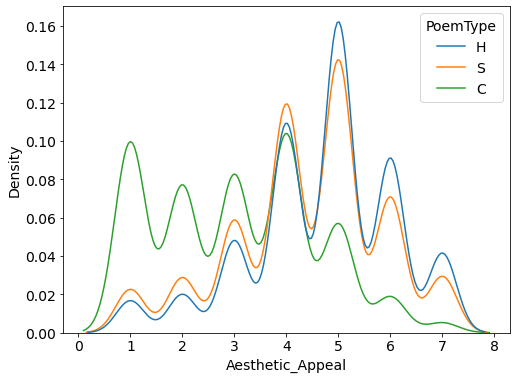

Distribution shape of Aesthetic_Appeal vs. Vivid_Imagery


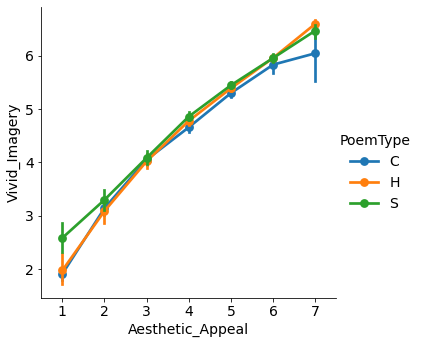

Distribution shape of Aesthetic_Appeal vs. Moved


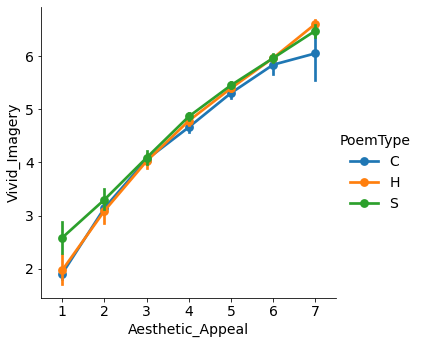

Distribution shape of Aesthetic_Appeal vs. Originality


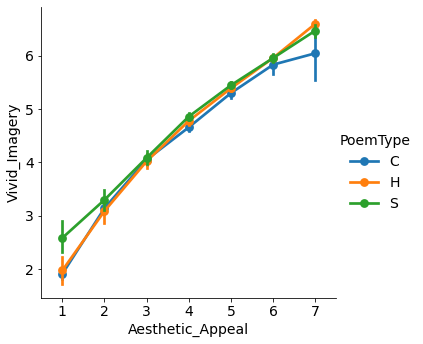

Distribution shape of Aesthetic_Appeal vs. Creativity


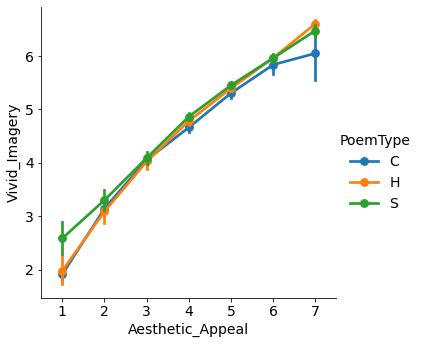

Distribution shape of Vivid_Imagery vs. Aesthetic_Appeal


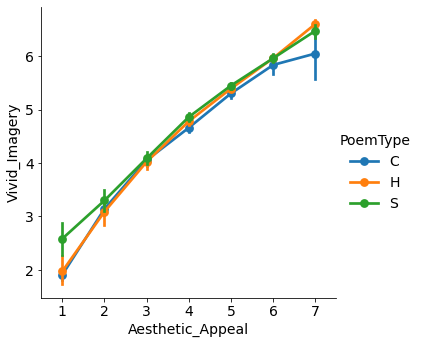

Distribution shape of Vivid_Imagery


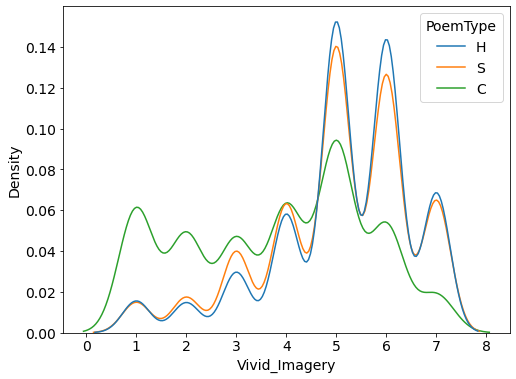

Distribution shape of Vivid_Imagery vs. Moved


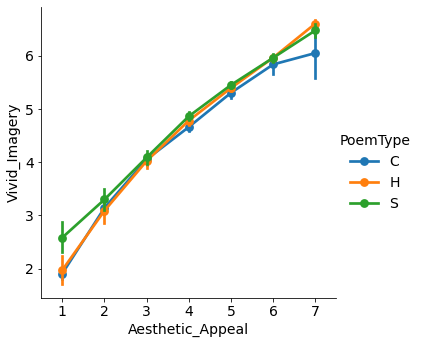

Distribution shape of Vivid_Imagery vs. Originality


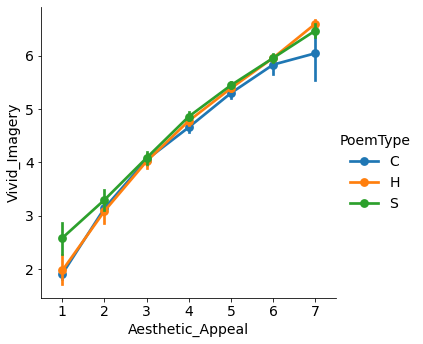

Distribution shape of Vivid_Imagery vs. Creativity


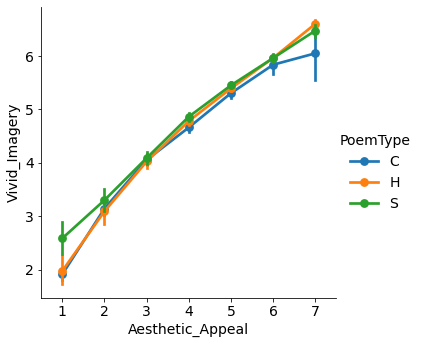

Distribution shape of Moved vs. Aesthetic_Appeal


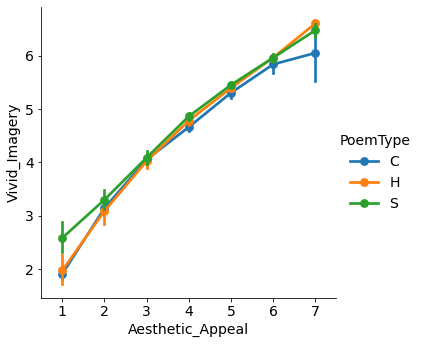

Distribution shape of Moved vs. Vivid_Imagery


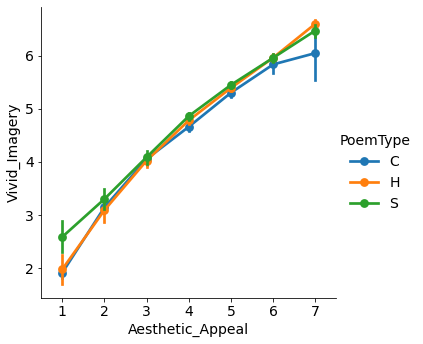

Distribution shape of Moved


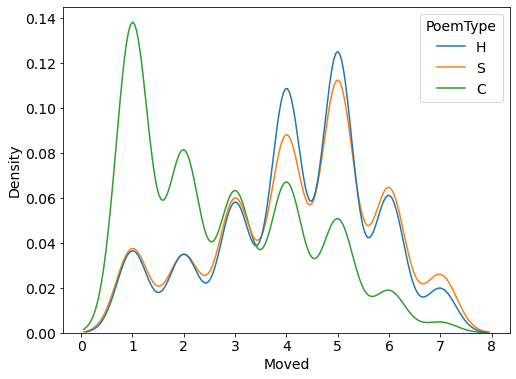

Distribution shape of Moved vs. Originality


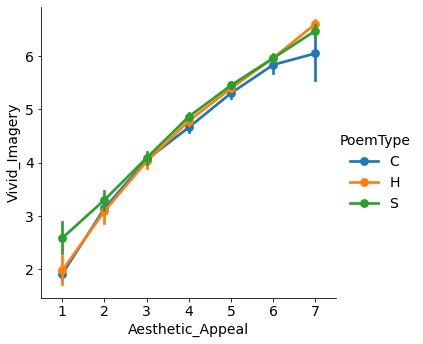

Distribution shape of Moved vs. Creativity


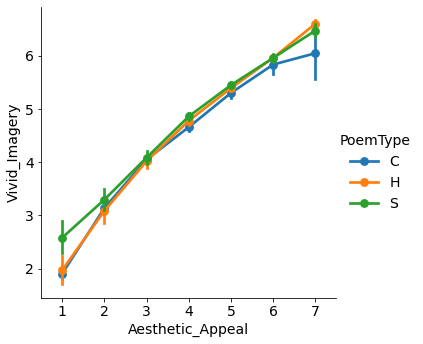

Distribution shape of Originality vs. Aesthetic_Appeal


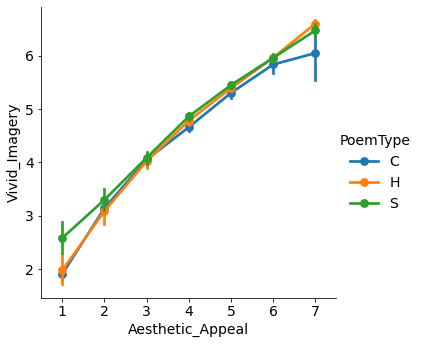

Distribution shape of Originality vs. Vivid_Imagery


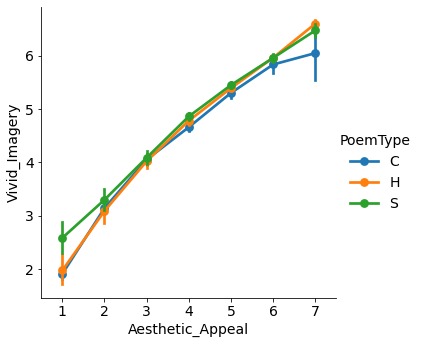

Distribution shape of Originality vs. Moved


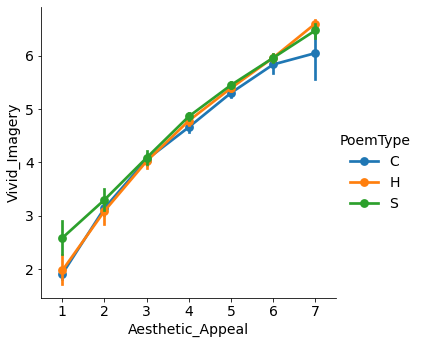

Distribution shape of Originality


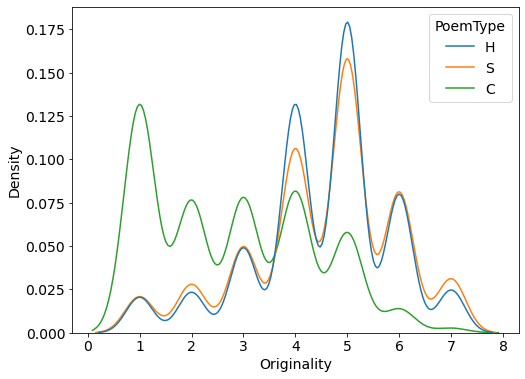

Distribution shape of Originality vs. Creativity


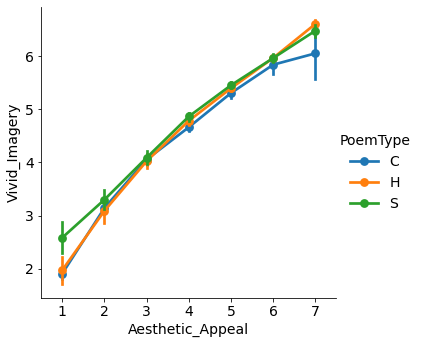

Distribution shape of Creativity vs. Aesthetic_Appeal


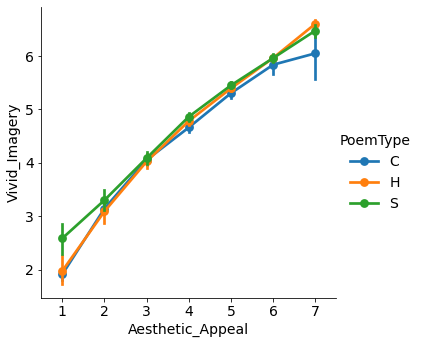

Distribution shape of Creativity vs. Vivid_Imagery


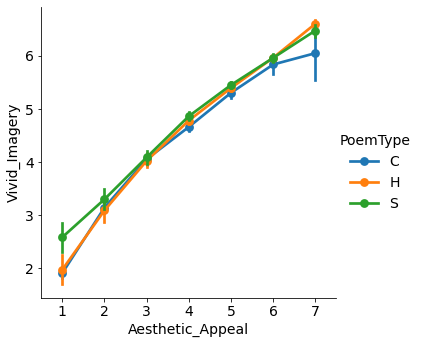

Distribution shape of Creativity vs. Moved


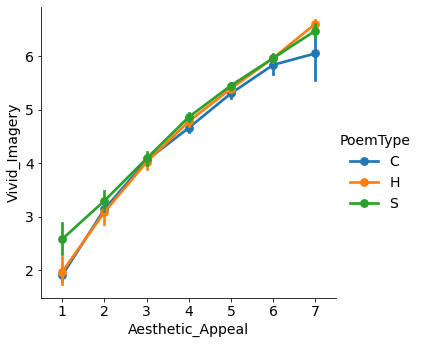

Distribution shape of Creativity vs. Originality


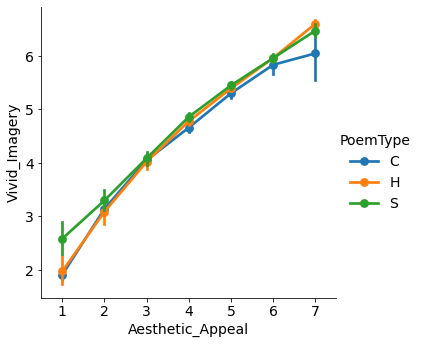

Distribution shape of Creativity


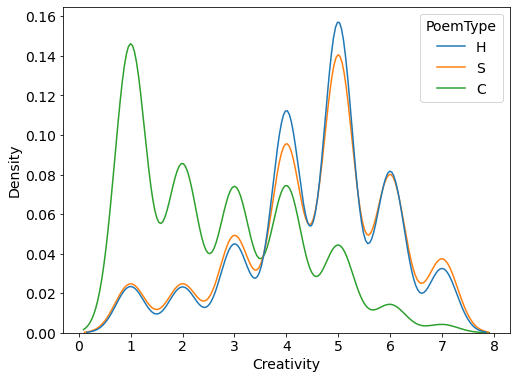

<Figure size 576x432 with 0 Axes>

In [17]:
# Loop over the columns of the dataframe
for i, col1 in enumerate(cols_scores[1:]):
    for j, col2 in enumerate(cols_scores[1:]):
        if i == j:
            # Diagonal plots
            print("Distribution shape of "+col1)
            sns.kdeplot(data = scores[cols_scores], x=col1, hue='PoemType')
            plt.show()
        else:
            # Off-diagonal plots
            print("Distribution shape of "+col1+" vs. "+col2)
            sns.catplot(data= scores[cols_scores], x=cols_scores[1], y=cols_scores[2], hue='PoemType', 
                        kind='point')
            plt.show()

plt.tight_layout()
plt.show()

Boxplots of Aesthetic_Appeal


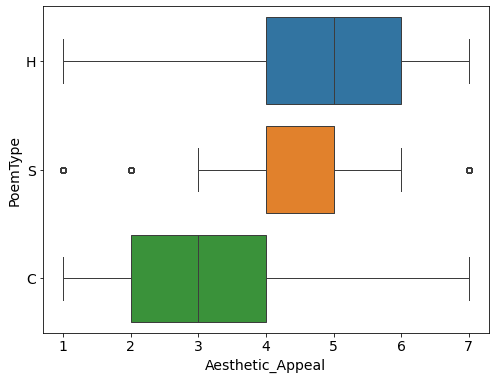

Boxplots of Vivid_Imagery


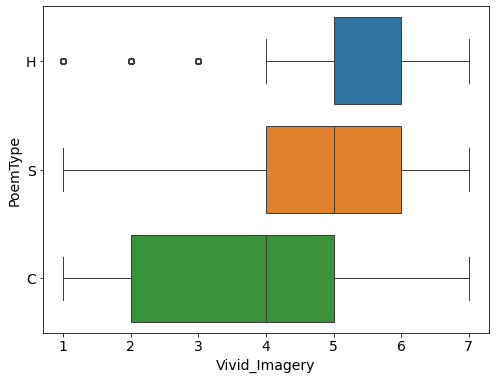

Boxplots of Moved


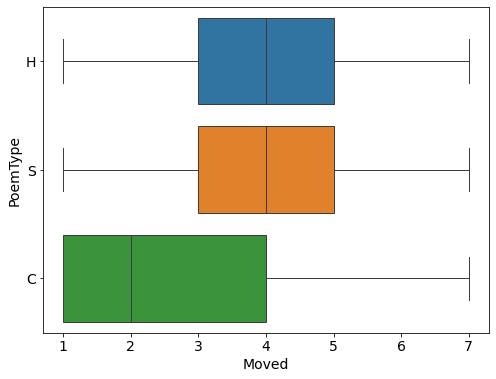

Boxplots of Originality


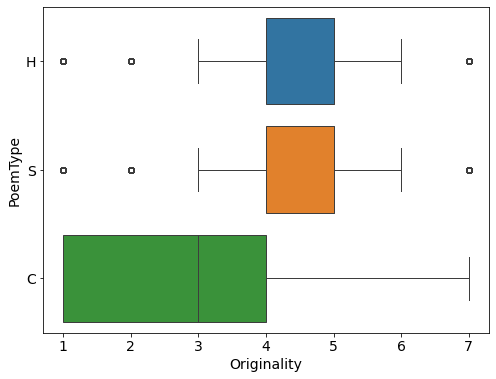

Boxplots of Creativity


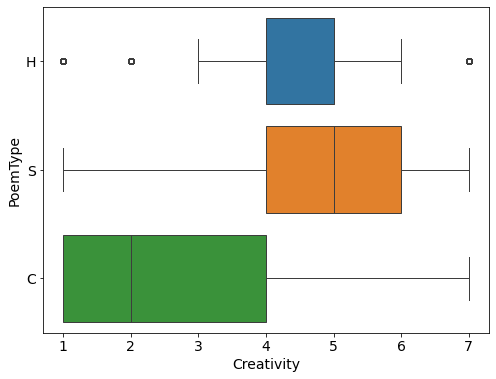

In [18]:
# Loop over the columns of the dataframe
for i, col1 in enumerate(cols_scores[1:]):
    for j, col2 in enumerate(cols_scores[1:]):
        if i == j:
            # Diagonal plots
            print("Boxplots of "+col1)
            sns.boxplot(data=scores[cols_scores], x=col1, y="PoemType", hue='PoemType')
            plt.show()

In [9]:
scores.columns

Index(['Participant', 'Poem', 'PoemType', 'Block', 'Aesthetic_Appeal',
       'Vivid_Imagery', 'Moved', 'Originality', 'Creativity', 'Openness_Mean',
       'Intellect_Mean', 'Curiosity_Mean', 'VVIQ_Mean', 'AVIQ_Mean',
       'Mindfulness_Mean', 'AReA_Mean'],
      dtype='object')

In [10]:
cols_target = ['Participant', 'PoemType','Aesthetic_Appeal',
       'Vivid_Imagery', 'Moved', 'Originality', 'Creativity']
cols_feat_personality = ['Participant','Openness_Mean',
       'Intellect_Mean', 'Curiosity_Mean', 'VVIQ_Mean', 'AVIQ_Mean',
       'Mindfulness_Mean', 'AReA_Mean']

In [11]:
df_target = scores[cols_target]
df_feat_personality = scores[cols_feat_personality]

In [12]:
df_target.to_csv('../project_eeg/data/target.csv')
df_feat_personality.to_csv('../project_eeg/data/features/personality_features.csv')